# Modules

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pingouin as pg

import seaborn as sns

from itertools import combinations
from scipy.stats import spearmanr

from longitudinal_arm_swing.constants import *
from longitudinal_arm_swing.utils import determine_affected_side_watch_side_mapping, calculate_pvalue, plot_significance, calculate_ci, bca_ci, split_into_two_lines

# Constants

In [2]:
clinical_data_file_name = 'clinical_data.parquet'
digital_measures_file_name = 'digital_measures.parquet'

updrs_score_map = {
    'updrs_2_total': 'Subscore UPDRS Part II',
}

for score_category in ['rigidity', 'bradykinesia', 'hypokinesia']:
    updrs_score_map[f'updrs_3_{score_category}_off_ws'] = f'{score_category.capitalize()} Part III OFF watch side'
    updrs_score_map[f'updrs_3_{score_category}_on_ws'] = f'{score_category.capitalize()} Part III ON watch side'
    updrs_score_map[f'updrs_3_{score_category}_off_non_ws'] = f'{score_category.capitalize()} Part III OFF non-watch side'
    updrs_score_map[f'updrs_3_{score_category}_on_non_ws'] = f'{score_category.capitalize()} Part III ON non-watch side'

aggregates = ['median', '95p', 'median_cov']
quantifications = ['range_of_motion']
measures = [f'{agg}_{quant}' for agg in aggregates for quant in quantifications]

segment_lengths = ['0_20', '20_inf']

cs_weeks = [1, 2]

save_plots = True

# Load

In [3]:
df_clinical = pd.read_parquet(os.path.join(PATH_CLINICAL_DATA, clinical_data_file_name))

df_measures = pd.read_parquet(os.path.join(BASE_PATH, 'measures', digital_measures_file_name))

with open(os.path.join(PATH_IDS, 'ids_remaining_after_exclusions.json'), 'r') as file:
    ids_remaining =  json.load(file)

with open(os.path.join(PATH_IDS, 'med_info_ids.json'), 'r') as file:
    med_info_ids = json.load(file)

# Prepare data

In [4]:
no_med_ids = med_info_ids['groups']['start_med']['ppp'] + med_info_ids['groups']['no_med']['ppp'] + med_info_ids['groups']['start_med']['denovo'] + med_info_ids['groups']['no_med']['denovo']
no_med_ids = set([x.replace('_no_med', '').replace('med', '') for x in no_med_ids])
med_ids = [x.replace('_no_med', '').replace('_med', '') for x in med_info_ids['groups']['med']['ppp'] + med_info_ids['groups']['med']['denovo']]
med_ids = set([x for x in med_ids if x not in no_med_ids])

cross_sectional_ids = ids_remaining['ppp']['cs'] + ids_remaining['denovo']['cs'] + ids_remaining['controls']['cs']

In [5]:
# Keep only cross-sectional data
df_clinical = df_clinical.loc[df_clinical['visit']==1]
df_measures = df_measures.loc[df_measures['week'].isin(cs_weeks)]

# Merge clinical data into measures
df = pd.merge(df_measures, df_clinical, on=['id', 'dataset', 'affected_side'], how='left')

# Remove participants which do not adhere to inclusion criteria
df = df.loc[df['id'].isin(cross_sectional_ids)]

df.loc[df['dataset'].isin(['ppp', 'denovo']), 'group'] = 'PD'
df.loc[df['dataset']=='controls', 'group'] = 'controls'

for dataset in df['dataset'].unique():
    print(f"Dataset: {dataset} -- N participants: {df.loc[df['dataset']==dataset, 'id'].nunique()}")

Dataset: ppp -- N participants: 357
Dataset: denovo -- N participants: 70
Dataset: controls -- N participants: 44


In [6]:
# Determine most affected side
df_pd_v1 = df_clinical.loc[(df_clinical['dataset'].isin(['ppp', 'denovo'])) & (df_clinical['visit'] == 1)].copy()

affected_side_mapping = {}
for method in ['rigidity', 'bradykinesia', 'hypokinesia']:
    affected_side_mapping[method] = determine_affected_side_watch_side_mapping(df_pd_v1, method)

# Process data
### RQ1 - Construct validity
1. Correlations: Spearman correlation MDS-UPDRS

In [7]:
df_cs = df.loc[(df['include_in_cross_sectional_analysis'] == True) & (df['week'] == 2)]

df_cs.to_parquet(os.path.join(BASE_PATH, 'measures', 'digital_measures_cross_sectional.parquet'), index=False)

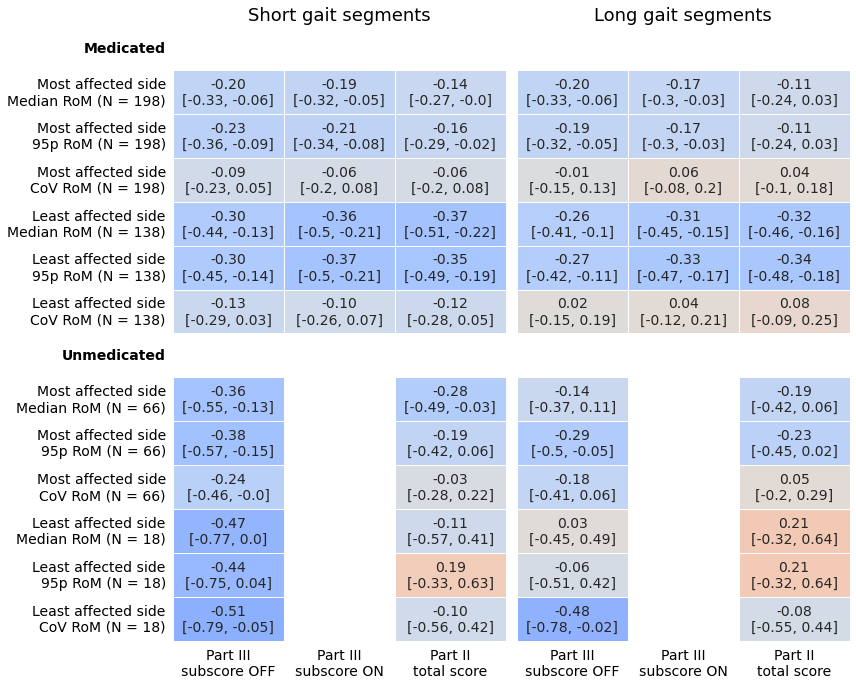

In [8]:
filter_type = 'filtered'
segment_lengths = ['0_20', '20_inf']

plot_vals = 'ci' # ci / pvals

clinical_scores = {
    'updrs_3_hypokinesia_off_ws': 'Part III\nsubscore OFF',
    'updrs_3_hypokinesia_on_ws': 'Part III\nsubscore ON',
    'updrs_2_total': 'Part II\ntotal score'
}

heatmap_data = {}
annot_data = {}

df_cs_plot = df_cs.loc[df_cs['filter_type'] == filter_type]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 10), sharey=True)

for j, segment_length in enumerate(segment_lengths):
    for med_status, med_status_ids in zip(['med', 'no_med'], [med_ids, no_med_ids]):
        for affected_side in ['mas', 'las']:
            for measure in measures:
                df_filtered = df_cs_plot.loc[
                    (df_cs_plot['id'].isin(med_status_ids)) &
                    (df_cs_plot['affected_side'] == affected_side) &
                    (df_cs_plot['segment_category'] == segment_length)
                ]

                if df_filtered.empty:
                    continue

                row_label = f'{GROUP_RENAMING[med_status].capitalize()} {affected_side.upper()}\n{measure.replace("_", " ").capitalize()} (N = {df_filtered.shape[0]})'
                x = df_filtered[measure]
                if x.isnull().all():
                    continue

                heatmap_data[row_label] = {}
                annot_data[row_label] = {}

                for clinical_score, clinical_label in clinical_scores.items():
                    y = df_filtered[clinical_score]
                    if y.isnull().all():
                        continue

                    valid_idx = (~x.isnull()) & (~y.isnull())
                    corr, p_val = spearmanr(x[valid_idx], y[valid_idx])
                    samples = df_filtered.loc[valid_idx, ['id', 'dataset']].drop_duplicates().shape[0]

                    if plot_vals == 'pvals':
                        if p_val < 0.001:
                            lower_label = '(p < 0.001)'
                        elif p_val < 0.01:
                            lower_label = '(p < 0.01)'
                        elif p_val < 0.05:
                            lower_label = '(p < 0.05)'
                        else:
                            lower_label = f'(p = {np.round(p_val, 2)})'
                    elif plot_vals == 'ci':
                        lower, upper = calculate_ci(x[valid_idx], corr)
                        lower_label = f'[{np.round(lower, 2)}, {np.round(upper, 2)}]'

                    heatmap_data[row_label][clinical_label] = corr
                    annot_data[row_label][clinical_label] = f"{corr:.2f}\n{lower_label}"

    corr_df = pd.DataFrame.from_dict(heatmap_data, orient='index')
    annot_df = pd.DataFrame.from_dict(annot_data, orient='index')

    row_order = list(corr_df.index)
    corr_df.loc['Medicated', :] = np.nan
    annot_df.loc['Medicated', :] = ""

    corr_df.loc['Unmedicated', :] = np.nan
    annot_df.loc['Unmedicated', :] = ""

    # Reorder so header rows are in correct place
    row_order = ['Medicated'] + row_order[:6] + ['Unmedicated'] + row_order[6:]
    corr_df = corr_df.loc[row_order]
    annot_df = annot_df.loc[row_order]

    corr_df.index = [x.replace('Medicated ', '').replace('Unmedicated ', '').replace('MAS', 'Most affected side').replace('LAS', 'Least affected side').replace('range of motion', 'RoM').replace('Median cov', 'CoV') for x in corr_df.index]
    annot_df.index = [x.replace('Medicated ', '').replace('Unmedicated ', '').replace('MAS', 'Most affected side').replace('LAS', 'Least affected side').replace('range of motion', 'RoM').replace('Median cov', 'CoV') for x in annot_df.index]

    # Plot
    sns.heatmap(
        corr_df,
        annot=annot_df,
        fmt="",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        cbar=False,
        vmin=-1, vmax=1,
        annot_kws={"size": PLOT_TEXTSIZE},
        ax=axes[j]
    )

    axes[j].tick_params(axis='both', which='major', labelsize=PLOT_TICKSIZE)
    plt.setp(axes[j].get_xticklabels(), rotation=0, fontsize=PLOT_TICKSIZE)
    plt.setp(axes[j].get_yticklabels(), fontsize=PLOT_TICKSIZE)

    yticks = axes[j].get_yticklabels()
    for tick in yticks:
        if tick.get_text() in ['Medicated', 'Unmedicated']:
            tick.set_fontweight('bold')
            tick.set_fontsize(PLOT_TICKSIZE)

    axes[j].tick_params(left=False, bottom=False)

axes[0].set_title('Short gait segments', fontsize=PLOT_TITLESIZE)
axes[1].set_title('Long gait segments', fontsize=PLOT_TITLESIZE)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

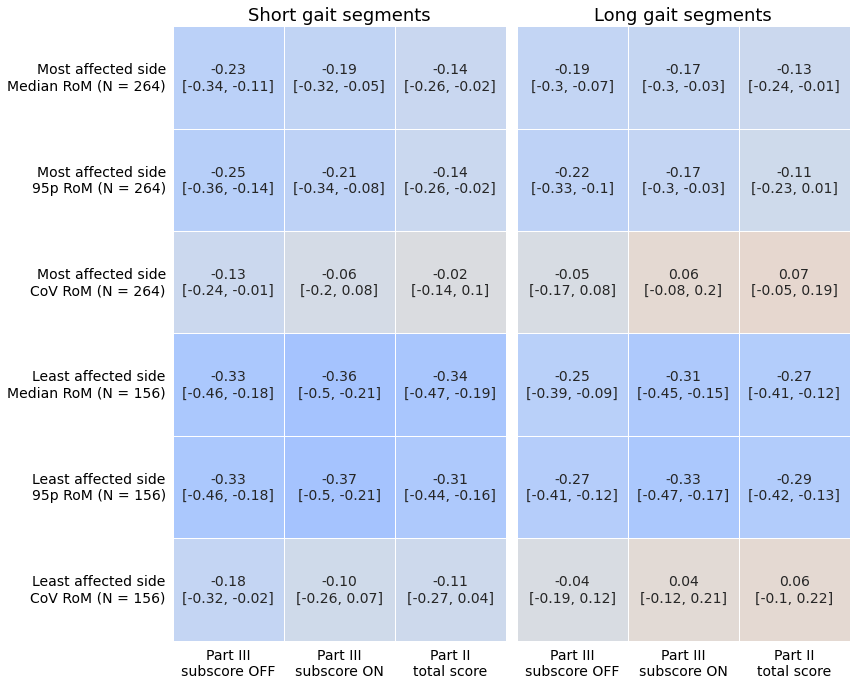

In [9]:
filter_type = 'filtered'
segment_lengths = ['0_20', '20_inf']
med_split = False  # True for separate med/no_med, False to combine

plot_vals = 'ci'  # ci / pvals

clinical_scores = {
    'updrs_3_hypokinesia_off_ws': 'Part III\nsubscore OFF',
    'updrs_3_hypokinesia_on_ws': 'Part III\nsubscore ON',
    'updrs_2_total': 'Part II\ntotal score'
}

df_cs_plot = df_cs.loc[df_cs['filter_type'] == filter_type]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 10), sharey=True)

if med_split:
    status_ids = zip(['med', 'no_med'], [med_ids, no_med_ids])
else:
    status_ids = [('all', list(med_ids) + list(no_med_ids))]

for j, segment_length in enumerate(segment_lengths):
    heatmap_data = {}
    annot_data = {}

    for med_status, med_status_ids in status_ids:
        for affected_side in ['mas', 'las']:
            for measure in measures:
                df_filtered = df_cs_plot.loc[
                    (df_cs_plot['id'].isin(med_status_ids)) &
                    (df_cs_plot['affected_side'] == affected_side) &
                    (df_cs_plot['segment_category'] == segment_length)
                ]

                if df_filtered.empty:
                    continue

                if med_split:
                    row_label = f'{GROUP_RENAMING[med_status].capitalize()} {affected_side.upper()}\n{measure.replace("_", " ").capitalize()} (N = {df_filtered.shape[0]})'
                else:
                    row_label = f'{affected_side.upper()}\n{measure.replace("_", " ").capitalize()} (N = {df_filtered.shape[0]})'

                x = df_filtered[measure]
                if x.isnull().all():
                    continue

                heatmap_data[row_label] = {}
                annot_data[row_label] = {}

                for clinical_score, clinical_label in clinical_scores.items():
                    y = df_filtered[clinical_score]
                    if y.isnull().all():
                        continue

                    valid_idx = (~x.isnull()) & (~y.isnull())
                    corr, p_val = spearmanr(x[valid_idx], y[valid_idx])

                    if plot_vals == 'pvals':
                        if p_val < 0.001:
                            lower_label = '(p < 0.001)'
                        elif p_val < 0.01:
                            lower_label = '(p < 0.01)'
                        elif p_val < 0.05:
                            lower_label = '(p < 0.05)'
                        else:
                            lower_label = f'(p = {np.round(p_val, 2)})'
                    elif plot_vals == 'ci':
                        lower, upper = calculate_ci(x[valid_idx], corr)
                        lower_label = f'[{np.round(lower, 2)}, {np.round(upper, 2)}]'

                    heatmap_data[row_label][clinical_label] = corr
                    annot_data[row_label][clinical_label] = f"{corr:.2f}\n{lower_label}"

    corr_df = pd.DataFrame.from_dict(heatmap_data, orient='index')
    annot_df = pd.DataFrame.from_dict(annot_data, orient='index')

    if med_split:
        row_order = list(corr_df.index)
        corr_df.loc['Medicated', :] = np.nan
        annot_df.loc['Medicated', :] = ""
        corr_df.loc['Unmedicated', :] = np.nan
        annot_df.loc['Unmedicated', :] = ""

        row_order = ['Medicated'] + row_order[:6] + ['Unmedicated'] + row_order[6:]
        corr_df = corr_df.loc[row_order]
        annot_df = annot_df.loc[row_order]

        corr_df.index = [x.replace('Medicated ', '').replace('Unmedicated ', '').replace('MAS', 'Most affected side').replace('LAS', 'Least affected side').replace('range of motion', 'RoM').replace('Median cov', 'CoV') for x in corr_df.index]
        annot_df.index = [x.replace('Medicated ', '').replace('Unmedicated ', '').replace('MAS', 'Most affected side').replace('LAS', 'Least affected side').replace('range of motion', 'RoM').replace('Median cov', 'CoV') for x in annot_df.index]
    else:
        corr_df.index = [x.replace('MAS', 'Most affected side').replace('LAS', 'Least affected side').replace('range of motion', 'RoM').replace('Median cov', 'CoV') for x in corr_df.index]
        annot_df.index = [x.replace('MAS', 'Most affected side').replace('LAS', 'Least affected side').replace('range of motion', 'RoM').replace('Median cov', 'CoV') for x in annot_df.index]

    sns.heatmap(
        corr_df,
        annot=annot_df,
        fmt="",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        cbar=False,
        vmin=-1, vmax=1,
        annot_kws={"size": PLOT_TEXTSIZE},
        ax=axes[j]
    )

    axes[j].tick_params(axis='both', which='major', labelsize=PLOT_TICKSIZE)
    plt.setp(axes[j].get_xticklabels(), rotation=0, fontsize=PLOT_TICKSIZE)
    plt.setp(axes[j].get_yticklabels(), fontsize=PLOT_TICKSIZE)
    axes[j].tick_params(left=False, bottom=False)

axes[0].set_title('Short gait segments', fontsize=PLOT_TITLESIZE)
axes[1].set_title('Long gait segments', fontsize=PLOT_TITLESIZE)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

if save_plots:
    fig.savefig(os.path.join(PATH_FIGURES, 'r_cs_corr.png'), dpi=600, bbox_inches='tight')
    fig.savefig(os.path.join(PATH_FIGURES, 'vectors', 'r_cs_corr.pdf'), dpi=600, bbox_inches='tight')


Processing measure: median
0_20: PD most
affected side vs PD least
affected side stat: -5.96 [-7.04, -4.61]; p-value:  p = 0.000
0_20: PD most
affected side vs Controls stat: -8.29 [-9.79, -5.08]; p-value:  p = 0.000
0_20: PD least
affected side vs Controls stat: -2.33 [-3.9, 1.05]; p-value:  p = 0.033
20_inf: PD most
affected side vs PD least
affected side stat: -9.75 [-13.11, -7.44]; p-value:  p = 0.000
20_inf: PD most
affected side vs Controls stat: -9.03 [-13.52, -4.54]; p-value:  p = 0.000
20_inf: PD least
affected side vs Controls stat: 0.73 [-4.45, 6.05]; p-value:  p = 0.958
Processing measure: 95p
0_20: PD most
affected side vs PD least
affected side stat: -13.16 [-16.41, -9.7]; p-value:  p = 0.000
0_20: PD most
affected side vs Controls stat: -20.97 [-24.39, -16.11]; p-value:  p = 0.000
0_20: PD least
affected side vs Controls stat: -7.81 [-11.77, -3.3]; p-value:  p = 0.026
20_inf: PD most
affected side vs PD least
affected side stat: -19.62 [-25.48, -14.03]; p-value:  p = 0.0

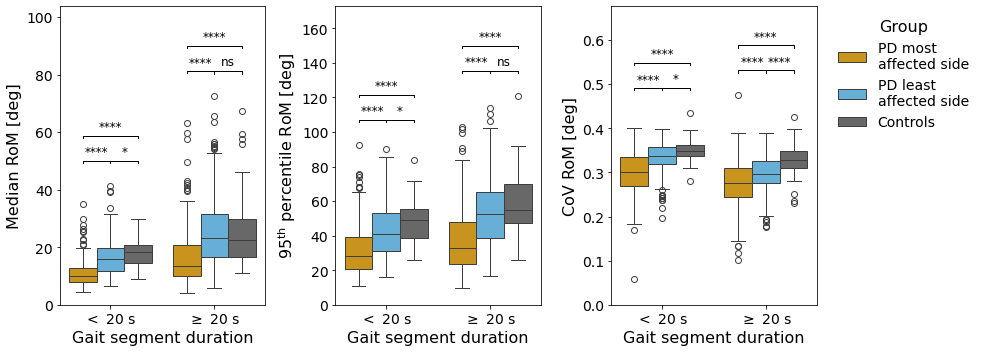

In [10]:
round_pval = False
med_state = None
filter_type = 'filtered'

if med_state in ['no_med', 'med']:
    df_cs_med_state = df_cs.loc[df_cs['med_state'] == med_state]
else:
    df_cs_med_state = df_cs.copy()

df_cs_med_state = df_cs_med_state.loc[(df_cs_med_state['filter_type'] == filter_type) & (df_cs_med_state['segment_category'].isin(segment_lengths))]

df_cs_med_state['affected_side'] = df_cs_med_state['affected_side'].fillna('')

df_cs_med_state.loc[(df_cs_med_state['group'] == 'PD') & (df_cs_med_state['affected_side'] == 'mas'), 'group_long'] = 'PD most\naffected side'
df_cs_med_state.loc[(df_cs_med_state['group'] == 'PD') & (df_cs_med_state['affected_side'] == 'las'), 'group_long'] = 'PD least\naffected side'
df_cs_med_state.loc[df_cs_med_state['group'] == 'controls', 'group_long'] = 'Controls'

groups = df_cs_med_state['group_long'].dropna().unique()

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(14,5), sharex=True)

for i, agg in enumerate(aggregates):
    print(f"Processing measure: {agg}")
    measure_full = f'{agg}_range_of_motion'

    sns.boxplot(x='segment_category', hue='group_long', y=measure_full, 
                data=df_cs_med_state, palette=[COLOR_GROUP_1, COLOR_GROUP_2, COLOR_GROUP_NEUTRAL], ax=ax[i])

    n_groups = len(groups)
    x_positions = {x_label: pos for x_label, pos in zip(segment_lengths, ax[i].get_xticks())}
    box_width = 0.8 / n_groups

    gap_y = np.max(df_cs_med_state[measure_full]) * 0.12

    box_positions = {}
    for length in segment_lengths:
        base_x = x_positions[length]
        for j, group in enumerate(groups):
            x = base_x - 0.4 + box_width * (j + 0.5)
            box_positions[(length, group)] = x

        sub_df = df_cs_med_state[df_cs_med_state['segment_category'] == length]
        present_groups = sub_df['group_long'].dropna().unique()
        max_y = sub_df[measure_full].max()

        for idx, (g1, g2) in enumerate(combinations(present_groups, 2)):
            values1 = sub_df[sub_df['group_long'] == g1][measure_full].dropna()
            values2 = sub_df[sub_df['group_long'] == g2][measure_full].dropna()

            p_value = calculate_pvalue(values1, values2, test='ranksums')[1]

            if round_pval:
                if p_value < 0.001:
                    p_value_str = 'p < 0.001'
                elif p_value < 0.01:
                    p_value_str = 'p < 0.01'
                elif p_value < 0.05:
                    p_value_str = 'p < 0.05'
                else:
                    p_value_str = f'p = {np.round(p_value, 2)}'
            else:
                p_value_str = f'p = {p_value:.3f}'

            pe_diff = np.median(values1) - np.median(values2)
            ci_lower, ci_upper = bca_ci(values1, values2, n_boot=2000, ci=95)

            print(f"{length}: {g1} vs {g2} stat: {np.round(pe_diff, 2)} [{np.round(ci_lower, 2)}, {np.round(ci_upper, 2)}]; p-value: ", p_value_str)

            x_min = box_positions[(length, g1)]
            x_max = box_positions[(length, g2)]

            if idx == 1:
                y_sig = max_y + 2 * gap_y
            else:
                y_sig = max_y + gap_y

            plot_significance(
                ax=ax[i],
                x_min=x_min,
                x_max=x_max,
                pvalue=p_value,
                y_min_significance=y_sig,
                text_size=PLOT_TEXTSIZE - 2,
            )

        
    ax[i].tick_params(axis='both', labelsize=PLOT_TICKSIZE)
    ax[i].set_ylim(0, 1.1 * ax[i].get_ylim()[1])
    ax[i].set_yticks(ax[i].get_yticks()[:-1])

    xticks = ax[i].get_xticks()
    xtick_labels = ax[i].get_xticklabels()

    new_labels = [
        SEGMENT_DURATION_RENAMING.get(label.get_text(), label.get_text())
        for label in xtick_labels
    ]

    ax[i].set_xticks(xticks)
    ax[i].set_xticklabels(new_labels, size=PLOT_TICKSIZE)

    ax[i].tick_params(axis='both', labelsize=PLOT_TICKSIZE)

    ylabel = f'{AGGREGATION_RENAMING[agg]} RoM [deg]'
    ax[i].set_ylabel(ylabel, size=PLOT_LABELSIZE)
    ax[i].set_xlabel('Gait segment duration', size=PLOT_LABELSIZE)

    if i == 2:
        ax[i].legend(title='Group', loc='upper right', title_fontsize=PLOT_LEGEND_FONTSIZE + 2, fontsize=PLOT_LEGEND_FONTSIZE, bbox_to_anchor=(1.8, 1), frameon=False)
    else:
        legend = ax[i].get_legend()
        if legend is not None:
            legend.remove()

fig.tight_layout()

plt.show()

if save_plots:
    fig.savefig(os.path.join(PATH_FIGURES, 'r_cs_group_diff_rom.png'), dpi=600, bbox_inches='tight')
    fig.savefig(os.path.join(PATH_FIGURES, 'vectors', 'r_cs_group_diff_rom.pdf'), dpi=600, bbox_inches='tight')

### RQ2 - Reliability
1. Test-retest

In [11]:
icc_type = 'ICC1'
filter_type = 'filtered'
segment_length = '20_inf'

df_icc = df.loc[
    (df['group'] == 'PD') &
    (df['include_in_icc_analysis']) &
    (df['week'].isin(cs_weeks)) & 
    (df['filter_type'] == filter_type) &
    (df['segment_category'] == segment_length)
].copy()

results = []

for side in ['mas', 'las']:  
    for agg, agg_label in AGGREGATION_RENAMING.items():
        df_side = df_icc[df_icc['affected_side'] == side]
        icc = pg.intraclass_corr(data=df_side, targets='id', raters='week', ratings=f'{agg}_range_of_motion', nan_policy='omit')

        results.append((
            f'{agg_label} RoM - {AFFECTED_SIDE_RENAMING[side]}',
            icc.loc[icc['Type'] == icc_type, 'ICC'].values[0],
            icc.loc[icc['Type'] == icc_type, 'pval'].values[0],
            icc.loc[icc['Type'] == icc_type, 'CI95%'].values[0]
        ))

df_icc = pd.DataFrame(results, columns=['Digital measure', 'ICC', 'p-value', 'CI95%'])

df_icc

,Digital measure,ICC,p-value,CI95%
0,Median RoM - Most affected side,0.910638,1.427562e-103,"[0.89, 0.93]"
1,95$^{\mathrm{th}}$ percentile RoM - Most affec...,0.938502,3.568010e-124,"[0.92, 0.95]"
2,CoV RoM - Most affected side,0.880604,7.386243e-88,"[0.85, 0.91]"
3,CoV RoM - Most affected side,0.868454,1.140111e-82,"[0.84, 0.9]"
4,SD RoM - Most affected side,0.950501,2.875074e-136,"[0.94, 0.96]"
5,SD RoM - Most affected side,0.925457,1.577286e-113,"[0.91, 0.94]"
6,Median RoM - Least affected side,0.888439,7.096306e-55,"[0.85, 0.92]"
7,95$^{\mathrm{th}}$ percentile RoM - Least affe...,0.916015,5.167721e-64,"[0.89, 0.94]"
8,CoV RoM - Least affected side,0.869233,7.815582e-50,"[0.82, 0.9]"
9,CoV RoM - Least affected side,0.835208,1.313790e-42,"[0.78, 0.88]"


#### Correlation between digital measures

<>:80: SyntaxWarning: invalid escape sequence '\g'
<>:80: SyntaxWarning: invalid escape sequence '\g'
C:\Users\z665206\AppData\Local\Temp\ipykernel_10688\1717676120.py:80: SyntaxWarning: invalid escape sequence '\g'
  ax[1].set_title('Long gait segment ($\geq$ 20 s)', size=PLOT_LABELSIZE)
C:\Users\z665206\AppData\Local\Temp\ipykernel_10688\1717676120.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


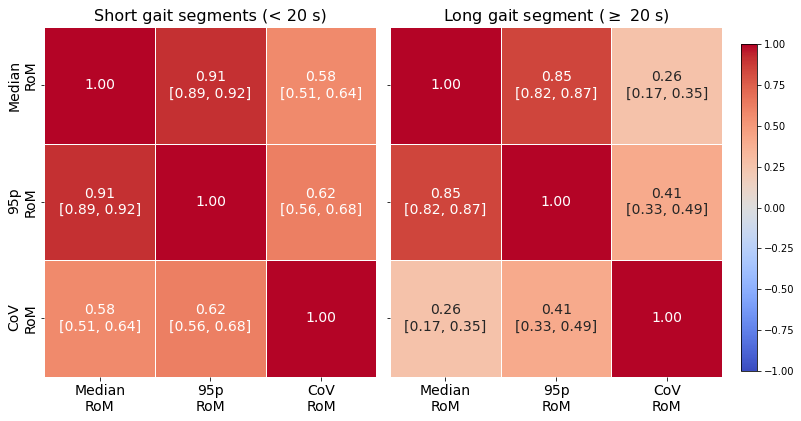

In [12]:
import seaborn as sns
from scipy.stats import spearmanr

plot_vals = 'ci'  # 'ci' or 'pvals'

fig, ax = plt.subplots(ncols=2, figsize=(12, 6), sharey=True)

df_corr = df.loc[
    (df['filter_type'] == 'filtered') &
    (df['group'] == 'PD') &
    (df['week'] == 1) & 
    (df['id'].isin(list(med_ids) + list(no_med_ids))),
]

for j, segment_length in enumerate(segment_lengths):
    df_segment = df_corr.loc[df_corr['segment_category'] == segment_length]

    if df_segment.empty:
        print(f"No data available for segment length: {segment_length}")
        continue

    median_rom = df_segment['median_range_of_motion'].values
    p_rom = df_segment['95p_range_of_motion'].values
    cv_rom = df_segment['median_cov_range_of_motion'].values

    corr_input_df = pd.DataFrame({
        'Median\nRoM': median_rom,
        '95p\nRoM': p_rom,
        'CoV\nRoM': cv_rom,
    })

    corr_df = corr_input_df.corr(method='spearman')
    annot_df = corr_df.copy().astype(str)

    for row in corr_df.columns:
        for col in corr_df.columns:
            if row == col:
                annot_df.loc[row, col] = "1.00"
                continue

            x = corr_input_df[row]
            y = corr_input_df[col]
            valid_idx = (~pd.isnull(x)) & (~pd.isnull(y))
            corr, p_val = spearmanr(x[valid_idx], y[valid_idx])

            if plot_vals == 'pvals':
                if p_val < 0.001:
                    lower_label = "(p < 0.001)"
                elif p_val < 0.01:
                    lower_label = "(p < 0.01)"
                elif p_val < 0.05:
                    lower_label = "(p < 0.05)"
                else:
                    lower_label = f"(p = {np.round(p_val, 2)})"
            elif plot_vals == 'ci':
                lower, upper = calculate_ci(x[valid_idx], corr)  # your helper
                lower_label = f"[{np.round(lower, 2)}, {np.round(upper, 2)}]"

            annot_df.loc[row, col] = f"{corr:.2f}\n{lower_label}"

    sns.heatmap(
        corr_df,
        annot=annot_df,
        fmt="",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        cbar=False,
        vmin=-1, vmax=1,
        annot_kws={"size": PLOT_TEXTSIZE},
        ax=ax[j]
    )

    ax[j].tick_params(axis='both', which='major', labelsize=PLOT_TICKSIZE)

im = ax[1].collections[0]
fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.05, pad=0.04)

ax[0].set_title('Short gait segments (< 20 s)', size=PLOT_LABELSIZE)
ax[1].set_title('Long gait segment ($\geq$ 20 s)', size=PLOT_LABELSIZE)

plt.tight_layout()
plt.subplots_adjust(top=0.92, right=0.84)
plt.show()


### Age vs digital measures

In [18]:
df_clinical.loc[df_clinical['dataset'] == 'controls']

,id,WatchSide,PrefHand,MotComOffStateTime,MotComDailyOffState,MotComDailyAwake,MotComDysKinTime,MotComDailyDysKin,Up3OfHoeYah,Age,...,dataset,visit,ledd,missing_med,AssessMonth,Up3OfParkMedic,affected_side,walking_aid,at_least_slight_dyskinesia,at_least_significant_dyskinesia
1770,POMU04E82999F61DF344,left,1.0,None,NaN,NaN,None,NaN,NaN,72.0,...,controls,1,NaN,NaN,NaN,NaN,None,False,False,False
1771,POMU080DB3462E1C36F3,left,1.0,None,NaN,NaN,None,NaN,NaN,53.0,...,controls,1,NaN,NaN,NaN,NaN,None,False,False,False
1772,POMU085AC68B87DB9BDA,left,1.0,None,NaN,NaN,None,NaN,NaN,66.0,...,controls,1,NaN,NaN,NaN,NaN,None,False,False,False
1773,POMU089C4E865CAC3420,right,1.0,None,NaN,NaN,None,NaN,NaN,72.0,...,controls,1,NaN,NaN,NaN,NaN,None,False,False,False
1774,POMU08EDA78A6C161ADD,left,1.0,None,NaN,NaN,None,NaN,NaN,51.0,...,controls,1,NaN,NaN,NaN,NaN,None,False,False,False
1775,POMU0A604ED7A5573D02,left,1.0,None,NaN,NaN,None,NaN,NaN,67.0,...,controls,1,NaN,NaN,NaN,NaN,None,False,False,False
1776,POMU1C46E9A5842A841D,left,1.0,None,NaN,NaN,None,NaN,NaN,58.0,...,controls,1,NaN,NaN,NaN,NaN,None,False,False,False
1777,POMU1CA776B8C2477DD4,right,1.0,None,NaN,NaN,None,NaN,NaN,77.0,...,controls,1,NaN,NaN,NaN,NaN,None,False,False,False
1778,POMU1CF6227B39191440,left,1.0,None,NaN,NaN,None,NaN,NaN,72.0,...,controls,1,NaN,NaN,NaN,NaN,None,False,False,False
1779,POMU26C9CD2026473AE6,left,1.0,None,NaN,NaN,None,NaN,NaN,70.0,...,controls,1,NaN,NaN,NaN,NaN,None,False,False,False


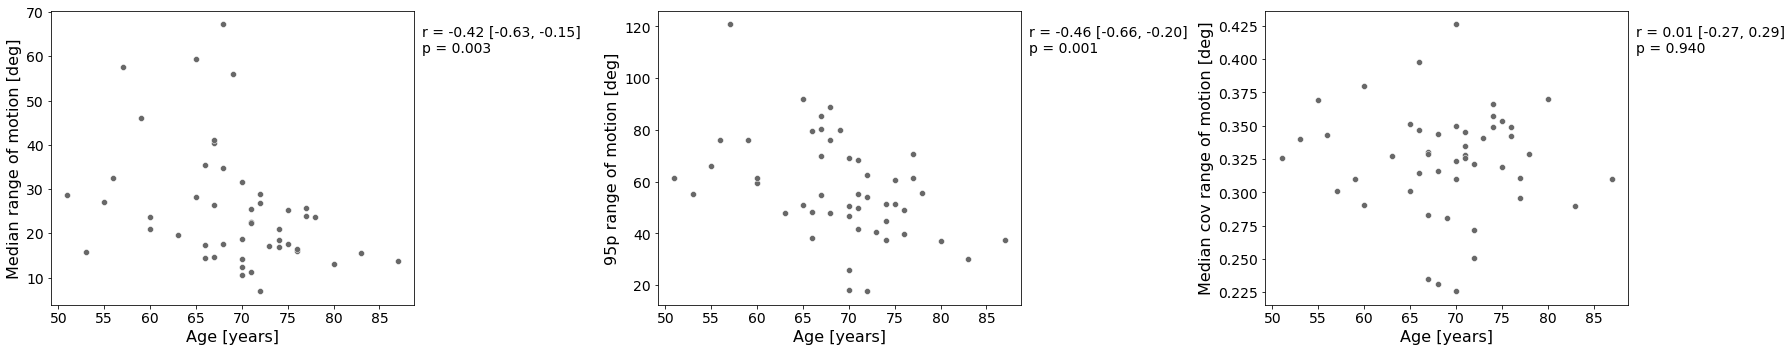

In [44]:
df_measures_controls = df_measures.loc[
    (df_measures['dataset'] == 'controls') &
    (df_measures['week'] == 2) & 
    (df_measures['filter_type'] == 'filtered') &
    (df_measures['segment_category'] == '20_inf')
].copy()

df_measures_controls = df_measures_controls.merge(
    df_clinical[['id', 'Age']],
    on='id', how='left'
)

fig, ax = plt.subplots(ncols=3, figsize=(25, 5), sharex=True)

for j, measure in enumerate(measures):
    sns.scatterplot(
        x='Age', y=measure,
        data=df_measures_controls,
        ax=ax[j],
        color=COLOR_GROUP_NEUTRAL
    )

    x = df_measures_controls['Age']
    y = df_measures_controls[measure]
    valid_idx = (~x.isnull()) & (~y.isnull())
    corr, p_val = spearmanr(x[valid_idx], y[valid_idx])

    lower, upper = calculate_ci(x[valid_idx], corr) 

    # print(f"{measure.replace('_', ' ').capitalize()} - Spearman's r = {corr:.2f} [{lower:.2f}, {upper:.2f}], p = {p_val:.3f}")
    ax[j].text(1.02, 0.95, f"r = {corr:.2f} [{lower:.2f}, {upper:.2f}]\np = {p_val:.3f}", transform=ax[j].transAxes, fontsize=PLOT_TEXTSIZE, verticalalignment='top', horizontalalignment='left')
    ax[j].set_xlabel('Age [years]', fontsize=PLOT_LABELSIZE)
    ax[j].set_ylabel(f'{measure.replace("_", " ").capitalize()} [deg]', fontsize=PLOT_LABELSIZE)
    ax[j].tick_params(axis='both', labelsize=PLOT_TICKSIZE)
    ax[j].grid(False)
    
plt.tight_layout()
plt.show()